**A/B-тест : геймификация в л/к ученика**
Гипотеза: Добавление системы достижений за регулярное решение задач повысит конверсию в прохождение модуля и удержание (Retention 7/14)

Дизайн: A - контроль (старый интерфейс), B - тест (геймификация). Случайное разделение, 3 недели (04.05–24.05.2026)

Структура: 1) чистка -> 2) метрики -> 3) воронка -> 4) распределения и выбор критерия -> 5) статистические тесты -> 6) сегментация и рекомендация

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import binomtest, chi2_contingency
ab_test_events = pd.read_csv('ab_test_events.csv',parse_dates = ['timestamp'])
ab_test_users_groups = pd.read_csv('ab_test_users_groups.csv',parse_dates = ['signup_date'])
ab_test_users_groups.head(5)

,user_id,group,signup_date,grade
0,U300000,B,2026-03-09,5
1,U300001,B,2025-09-07,9
2,U300002,B,2026-01-11,9
3,U300003,A,2025-06-07,5
4,U300004,B,2025-12-25,11


In [2]:
ab_test_events.head(5)

,user_id,timestamp,event_type
0,U300281,2026-05-04 00:06:44,homework_completed
1,U300733,2026-05-04 00:19:56,homework_completed
2,U304499,2026-05-04 00:22:07,login
3,U304266,2026-05-04 00:23:42,homework_started
4,U304266,2026-05-04 00:23:42,homework_started


In [3]:
# проверим SRM на сырых данных

split_raw = ab_test_users_groups.drop_duplicates('user_id' , keep = False).group.value_counts()
srm = binomtest(split_raw['A'], split_raw.sum(), p = 0.5)
print(split_raw.to_dict(), f"p-value = {srm.pvalue}")

{'A': 2997, 'B': 2995} p-value = 0.9896929106854582


Видим, что p-value = 0.9897, что говорит о том, что SRM не обнаружен, сплит в норме
Проверяем до очистки: SRM тестирует рандомизатор, а не данные. Если сначала удалить ботов, мы проверим собственный фильтр. кросс групповые дубли удаляем и здесь — юзер физически не может быть в двух группах, счётчик стал бы неверным

In [4]:
#ищу тех юзеров, которые попали в обе группы
cross = ab_test_users_groups.groupby('user_id')['group'].nunique()
cross_id = set(cross[cross > 1].index)

events = ab_test_events.drop_duplicates()

cnt = events.groupby('user_id').size().sort_values(ascending = False)
cnt.head(20)
#видим что есть юзеры с >711 действиями, что говорит о скриптах, а не очень усердных людях
#удалять их нужно чтобы искусственно не увеличивалась дисперсия
bots = set(cnt[cnt > 200].index)
to_drop = bots | cross_id
users = ab_test_users_groups[~ab_test_users_groups.user_id.isin(to_drop)]
events = events[~events.user_id.isin(to_drop)]


Три источника загрязнения:

1. Кросс групповые (8 юзеров). keep=False удаляет обе строки дубля: неизвестно, какое назначение настоящее, а выбор "первого" означал бы выбор по порядку строк в файле

2. Полные дубли событий (2 строки) — ошибка логирования

3. Боты (12 юзеров). В распределении активности разрыв: 12 аккаунтов имеют 711–842 события, следующий после них — 52. Порог 200 поставлен в пустоту, поэтому результат к нему не чувствителен (150, 200, 400 дают ту же выборку)


In [5]:
users

,user_id,group,signup_date,grade
0,U300000,B,2026-03-09,5
1,U300001,B,2025-09-07,9
2,U300002,B,2026-01-11,9
3,U300003,A,2025-06-07,5
4,U300004,B,2025-12-25,11
...,...,...,...,...
5995,U305995,A,2025-09-03,8
5996,U305996,B,2025-07-22,6
5997,U305997,A,2025-08-08,5
5998,U305998,A,2026-03-21,6


In [6]:
sp = users.group.value_counts()
r = binomtest(sp['A'], sp.sum(), p = 0.5)
crosstab = pd.crosstab(users.grade, users.group)
chi2, p, dof, _ = chi2_contingency(crosstab)
print(f"chi2 = {chi2}, p-value = {p}, dof = {dof}, r_p-value = {r.pvalue}")

chi2 = 8.01189252397131, p-value = 0.23723332342252845, dof = 6, r_p-value = 0.9690546244930447


как видим, данные в порядке: p = 0.237 -> значимого дисбаланса нет. Любая обнаруженная далее разница объясняется фичей, а не различием аудиторий.
Повторный SRM отвечает на другой вопрос: не перекосил ли группы наш собственный фильтр

In [7]:
counts = events.pivot_table(
    index = 'user_id',
    columns = 'event_type',
    values = 'timestamp',
    aggfunc = 'count'
).fillna(0).astype(int)
counts.columns.name = None

df = users.set_index('user_id').join(counts, how = 'left').fillna(0)
df

,group,signup_date,grade,homework_completed,homework_started,login,return_visit_d14,return_visit_d7
user_id,,,,,,,,
U300000,B,2026-03-09,5,6,11,14,1,1
U300001,B,2025-09-07,9,3,11,14,1,1
U300002,B,2026-01-11,9,4,11,12,1,1
U300003,A,2025-06-07,5,3,10,10,1,1
U300004,B,2025-12-25,11,3,12,13,0,1
...,...,...,...,...,...,...,...,...
U305995,A,2025-09-03,8,4,13,16,0,1
U305996,B,2025-07-22,6,4,11,12,0,1
U305997,A,2025-08-08,5,3,12,13,1,1


Основная метрика — completion_rate = homework_completed / homework_started на пользователя

Почему не "завершил хотя бы одну": метрика слишком и так высока (97.6% vs 98.8%), различать нечего, оставляем как поддерживающую

Почему не отношение суммарных событий: это ratio-метрика, где активный юзер весит больше пассивного, а задачи внутри юзера зависимы. Тесты для долей к ней неприменимы

Единица рандомизации — пользователь, поэтому одно наблюдение = один пользователь

In [8]:
#целевая метрика - процент выполненных домашних заданий
df['completion_rate'] = df['homework_completed'] / df['homework_started']

#начиналось ли вообще вообще решение задач из домашки(минимум 1 выполненное задание)
df['completed_any'] = (df['homework_completed'] > 0).astype(int)

#ретеншн
df['retention_d7'] = (df['return_visit_d7'] > 0).astype(int)
df['retention_d14'] = (df['return_visit_d14'] > 0).astype(int)
df

,group,signup_date,grade,homework_completed,homework_started,login,return_visit_d14,return_visit_d7,completion_rate,completed_any,retention_d7,retention_d14
user_id,,,,,,,,,,,,
U300000,B,2026-03-09,5,6,11,14,1,1,0.545455,1,1,1
U300001,B,2025-09-07,9,3,11,14,1,1,0.272727,1,1,1
U300002,B,2026-01-11,9,4,11,12,1,1,0.363636,1,1,1
U300003,A,2025-06-07,5,3,10,10,1,1,0.300000,1,1,1
U300004,B,2025-12-25,11,3,12,13,0,1,0.250000,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
U305995,A,2025-09-03,8,4,13,16,0,1,0.307692,1,1,0
U305996,B,2025-07-22,6,4,11,12,0,1,0.363636,1,1,0
U305997,A,2025-08-08,5,3,12,13,1,1,0.250000,1,1,1


TTV = часы от первого логина до первой завершённой домашки

In [9]:
first_login = (events[events['event_type'] == 'login'].groupby('user_id')['timestamp'].min())
first_done = (events[events['event_type'] == 'homework_completed'].groupby('user_id')['timestamp'].min())

ttv = (first_done - first_login).dt.total_seconds() / 3600
df['time_to_value_hours'] = df.index.map(ttv)
df

,group,signup_date,grade,homework_completed,homework_started,login,return_visit_d14,return_visit_d7,completion_rate,completed_any,retention_d7,retention_d14,time_to_value_hours
user_id,,,,,,,,,,,,,
U300000,B,2026-03-09,5,6,11,14,1,1,0.545455,1,1,1,167.633333
U300001,B,2025-09-07,9,3,11,14,1,1,0.272727,1,1,1,188.950000
U300002,B,2026-01-11,9,4,11,12,1,1,0.363636,1,1,1,97.066667
U300003,A,2025-06-07,5,3,10,10,1,1,0.300000,1,1,1,117.583333
U300004,B,2025-12-25,11,3,12,13,0,1,0.250000,1,1,0,0.816667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
U305995,A,2025-09-03,8,4,13,16,0,1,0.307692,1,1,0,169.183333
U305996,B,2025-07-22,6,4,11,12,0,1,0.363636,1,1,0,0.683333
U305997,A,2025-08-08,5,3,12,13,1,1,0.250000,1,1,1,0.516667


In [10]:
metrics = ['completion_rate', 'completed_any', 'retention_d7', 'retention_d14', 'time_to_value_hours']
summary = df.groupby('group')[metrics].mean().T
summary.loc['time_to_value_hours'] = df.groupby('group')['time_to_value_hours'].median()
summary['abs_diff'] = summary['B'] - summary['A']
summary['rel_diff_%'] = summary['abs_diff'] / summary['A'] * 100
summary

group,A,B,abs_diff,rel_diff_%
completion_rate,0.346066,0.437967,0.091901,26.556025
completed_any,0.976270,0.988286,0.012016,1.230851
retention_d7,0.726939,0.779786,0.052847,7.269846
retention_d14,0.288102,0.362450,0.074348,25.806241
time_to_value_hours,50.283333,25.233333,-25.050000,-49.817700


Воронка

In [11]:
# объединим события и группы
ev = events.merge(users[['user_id', 'group']], on = 'user_id')
steps = ['login', 'homework_started', 'homework_completed']

total = users.groupby('group').size()
funnel_u = (ev[ev.event_type.isin(steps)].groupby(['group', 'event_type'])['user_id'].nunique().unstack()[steps])
print('воронка по пользователям')
display((funnel_u.div(total, axis=0) * 100).round(2))

funnel_e = (ev[ev.event_type.isin(steps)].groupby(['group', 'event_type']).size().unstack()[steps])
print('воронка по задачам')
display(funnel_e)

воронка по пользователям


event_type,login,homework_started,homework_completed
group,,,
A,100.0,100.0,97.63
B,100.0,100.0,98.83


воронка по задачам


event_type,login,homework_started,homework_completed
group,,,
A,34442,30999,10712
B,37862,34109,15259


Воронка строится на двух уровнях, и они отвечают на разные вопросы.

По пользователям она вырождена: 100% -> 100% -> 97.6%/98.8%

In [12]:
s = pd.DataFrame({
    'login -> started':     funnel_e['homework_started']   / funnel_e['login'] * 100,
    'started -> completed': funnel_e['homework_completed'] / funnel_e['homework_started'] * 100,
    'login -> completed':   funnel_e['homework_completed'] / funnel_e['login'] * 100,
})
display(s.round(2))

per_user = funnel_e.div(total, axis = 0)
print('событий на пользователя')
display(per_user.round(2))
print('прирост B к А, %')
display(((per_user.loc['B'] / per_user.loc['A'] - 1) * 100).round(2))

a, b = per_user.loc['A'], per_user.loc['B']
cr_a =  a['homework_completed'] / a['homework_started']
cr_b =  b['homework_completed'] / b['homework_started']

print(f"стартов на юзера:     {a['homework_started']:.2f} -> {b['homework_started']:.2f}"
      f"  ({(b['homework_started']/a['homework_started']-1)*100:+.1f}%)")
print(f"доля доведённых:      {cr_a:.4f} -> {cr_b:.4f}  ({(cr_b/cr_a-1)*100:+.1f}%)")
print(f"завершений на юзера:  {a['homework_completed']:.2f} -> {b['homework_completed']:.2f}"
      f"  ({(b['homework_completed']/a['homework_completed']-1)*100:+.1f}%)")

,login -> started,started -> completed,login -> completed
group,,,
A,90.00,34.56,31.1
B,90.09,44.74,40.3


событий на пользователя


event_type,login,homework_started,homework_completed
group,,,
A,11.51,10.36,3.58
B,12.67,11.42,5.11


прирост B к А, %


event_type
login                 10.08
homework_started      10.18
homework_completed    42.64
dtype: float64

стартов на юзера:     10.36 -> 11.42  (+10.2%)
доля доведённых:      0.3456 -> 0.4474  (+29.5%)
завершений на юзера:  3.58 -> 5.11  (+42.6%)


По задачам видно главное различие: на первом шаге группы неотличимо, но на втором уже видно прирост в 10,2%. Это и показывает механику фичи: достижения даются за доведение задач до конца, что стимулирует закончить домашку

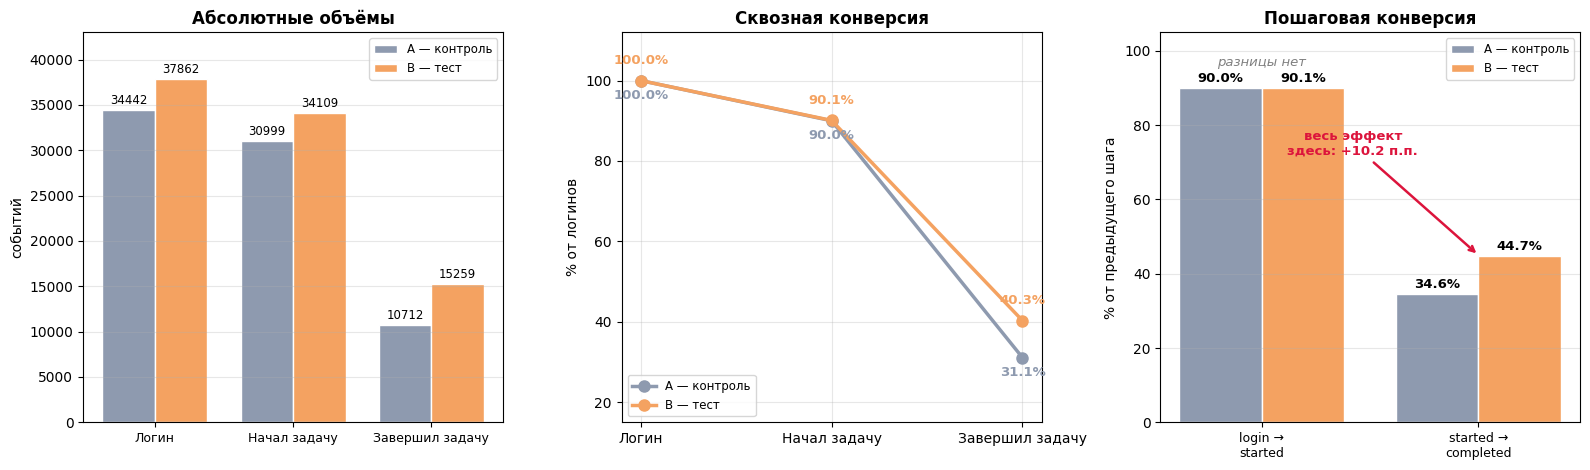

In [13]:
import matplotlib.pyplot as plt
#построено с помощью LLM


funnel_pct = funnel_e.div(funnel_e['login'], axis=0) * 100
PALETTE = {'A': '#8E9AAF', 'B': '#F4A261'}
NAMES   = {'A': 'A — контроль', 'B': 'B — тест'}
LABELS = ['Логин', 'Начал задачу', 'Завершил задачу']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
x, w = np.arange(3), 0.38

# --- 1. абсолютные объёмы ---
ax = axes[0]
for i, g in enumerate(['A', 'B']):
    bars = ax.bar(x + (i - .5) * w, funnel_e.loc[g], w,
                  color=PALETTE[g], edgecolor='white', label=NAMES[g])
    ax.bar_label(bars, fmt='%d', fontsize=8.5, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=9)
ax.set_ylabel('событий'); ax.set_ylim(0, 43000)
ax.set_title('Абсолютные объёмы', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=.3)

# --- 2. сквозная конверсия ---
ax = axes[1]
offset = {'A': -13, 'B': 12}          # разводим подписи, иначе налезают
for g in ['A', 'B']:
    ax.plot(LABELS, funnel_pct.loc[g], marker='o', ms=8, lw=2.5,
            color=PALETTE[g], label=NAMES[g])
    for xi, yi in zip(LABELS, funnel_pct.loc[g]):
        ax.annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points',
                    xytext=(0, offset[g]), ha='center', fontsize=9.5,
                    color=PALETTE[g], fontweight='bold')
ax.set_ylabel('% от логинов'); ax.set_ylim(15, 112)
ax.set_title('Сквозная конверсия', fontweight='bold')
ax.legend(loc='lower left', fontsize=8.5); ax.grid(alpha=.3)

# --- 3. пошаговая конверсия ---
ax = axes[2]
step_conv = pd.DataFrame({
    'login →\nstarted':     funnel_e['homework_started']   / funnel_e['login'] * 100,
    'started →\ncompleted': funnel_e['homework_completed'] / funnel_e['homework_started'] * 100,
})
x2 = np.arange(2)
for i, g in enumerate(['A', 'B']):
    bars = ax.bar(x2 + (i - .5) * w, step_conv.loc[g], w,
                  color=PALETTE[g], edgecolor='white', label=NAMES[g])
    ax.bar_label(bars, fmt='%.1f%%', fontsize=9.5, padding=2, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(step_conv.columns, fontsize=9)
ax.set_ylabel('% от предыдущего шага'); ax.set_ylim(0, 105)
ax.set_title('Пошаговая конверсия', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=.3)

gap = step_conv.loc['B'].iloc[1] - step_conv.loc['A'].iloc[1]
ax.annotate(f'весь эффект\nздесь: +{gap:.1f} п.п.', xy=(1, 45), xytext=(0.42, 72),
            fontsize=9.5, color='crimson', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
ax.text(0, 96, 'разницы нет', fontsize=9.5, color='gray', ha='center', style='italic')

plt.tight_layout()
plt.show()

In [14]:
a, b = df.loc[df.group == 'A', 'completion_rate'].values, df.loc[df.group == 'B', 'completion_rate'].values

print(f" A: n = {len(a)},\n B: n = {len(b)}")


 A: n = 2992,
 B: n = 2988


In [15]:
display(df.groupby('group')['completion_rate'].describe().round(4))

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2992.0,0.3461,0.1561,0.0,0.2500,0.3333,0.4444,0.9091
B,2988.0,0.4380,0.1809,0.0,0.3077,0.4444,0.5714,1.0000


In [16]:
#форма распределения
from scipy import stats
for name, x in [('A', a), ('B', b)]:
    print(f'{name}: skew = {stats.skew(x):+.3f}, kurtosis = {stats.kurtosis(x):+.3f}')

A: skew = +0.202, kurtosis = -0.022
B: skew = +0.001, kurtosis = -0.381


In [17]:
#формальный тест нормальности Шапиро-Уилка
rng = np.random.default_rng(42)
for name, x in [('A', a), ('B', b)]:
    sub = rng.choice(x, 2000, replace = False)
    W, p = stats.shapiro(sub)
    print(f'{name}: W = {W:.4f}, p = {p:.2e}')

A: W = 0.9927, p = 2.07e-08
B: W = 0.9959, p = 2.57e-05


значит, данные распределены не нормально. Оценка формы (skew = 0.20, kurtosis ≈ 0) показывает распределение, близкое к симметричному. Решение о применимости t-теста принимается по величине отклонения и по проверке нормальности выборочного среднего

In [18]:
# проверка равенства дисперсий

W_lev, p_lev = stats.levene(a, b, center = 'median')
print(f"std A = {a.std(ddof = 1):.4f}, std B = {b.std(ddof = 1):.4f}")
print(f"W_lev = {W_lev},\np_lev = {p_lev}")

std A = 0.1561, std B = 0.1809
W_lev = 81.39875211655117,
p_lev = 2.444068161040251e-19


p_value мал => дисперсии различаются

На основе всех данных можно взять t-test Уэлча так как дисперсии не равны, основная метрика непрерывная со значениями от 0 до 1

Бутстрап (5000 повторов) строит эмпирическое распределение выборочного среднего группы A.


In [19]:
means = np.array([rng.choice(a, len(a), replace = True).mean() for _ in range(5000)])
W_m, p_m = stats.shapiro(rng.choice(means, 2000, replace = False))
print(f"skew средних = {stats.skew(means):.4f}")
print(f"W_m = {W_m},\np_m = {p_m}")

skew средних = -0.0152
W_m = 0.9988901993859693,
p_m = 0.24229883352491732


skew = -0.0152, Shapiro p = 0.25 → нормальность не отвергается.

Именно это и требуется для t-теста: по ЦПТ при n = 3000 среднее распределено нормально практически при любой форме исходных данных.

снизу посчитаем кол-во выбросов

In [20]:
for name, x in [('A', a), ('B', b)]:
    q1, q3 = np.percentile(x,[25,75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    print(f"{name}: границы [{lo:.3f}, {hi:.3f}], выбросов: {((x < lo) | (x > hi)).sum()}")

A: границы [-0.042, 0.736], выбросов: 26
B: границы [-0.088, 0.967], выбросов: 4


выброс здесь - отличник, а такое различие из-за самой фичи

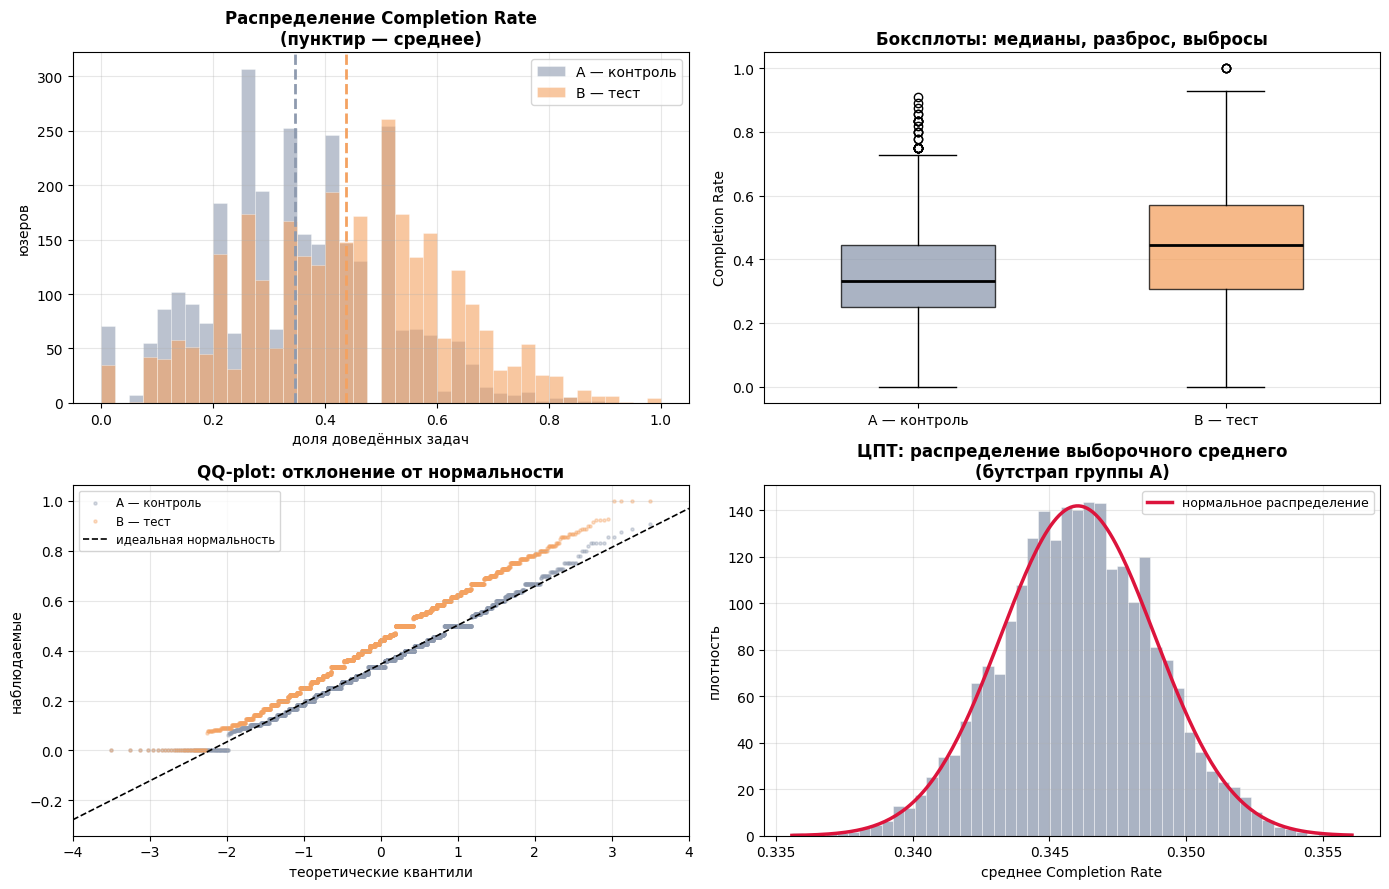

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- гистограммы ---
ax = axes[0,0]
bins = np.linspace(0, 1, 41)
for g, x in [('A', a), ('B', b)]:
    ax.hist(x, bins=bins, alpha=.6, color=PALETTE[g], label=NAMES[g],
            edgecolor='white', lw=.4)
    ax.axvline(x.mean(), color=PALETTE[g], ls='--', lw=2)
ax.set_title('Распределение Completion Rate\n(пунктир — среднее)', fontweight='bold')
ax.set_xlabel('доля доведённых задач'); ax.set_ylabel('юзеров')
ax.legend(); ax.grid(alpha=.3)

# --- боксплоты ---
ax = axes[0,1]
bp = ax.boxplot([a, b], tick_labels=[NAMES['A'], NAMES['B']],
                patch_artist=True, widths=.5, medianprops=dict(color='black', lw=2))
for patch, g in zip(bp['boxes'], ['A', 'B']):
    patch.set_facecolor(PALETTE[g]); patch.set_alpha(.75)
ax.set_title('Боксплоты: медианы, разброс, выбросы', fontweight='bold')
ax.set_ylabel('Completion Rate'); ax.grid(axis='y', alpha=.3)

# --- QQ-plot ---
ax = axes[1,0]
for g, x in [('A', a), ('B', b)]:
    osm, osr = stats.probplot(x, dist='norm', fit=False)
    ax.scatter(osm, osr, s=5, alpha=.35, color=PALETTE[g], label=NAMES[g])
ax.plot([-4, 4], [np.mean(a) + np.std(a)*z for z in (-4, 4)], 'k--', lw=1.2,
        label='идеальная нормальность')
ax.set_xlim(-4, 4)
ax.set_title('QQ-plot: отклонение от нормальности', fontweight='bold')
ax.set_xlabel('теоретические квантили'); ax.set_ylabel('наблюдаемые')
ax.legend(fontsize=8.5); ax.grid(alpha=.3)

# --- ЦПТ ---
ax = axes[1,1]
ax.hist(means, bins=50, color=PALETTE['A'], alpha=.75,
        edgecolor='white', lw=.4, density=True)
xs = np.linspace(means.min(), means.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, means.mean(), means.std()), 'crimson', lw=2.5,
        label='нормальное распределение')
ax.set_title('ЦПТ: распределение выборочного среднего\n(бутстрап группы A)', fontweight='bold')
ax.set_xlabel('среднее Completion Rate'); ax.set_ylabel('плотность')
ax.legend(fontsize=9); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

In [22]:
#далее пойдут статистические тесты
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

In [23]:
Alpha = 0.05 #standart

def t_test(a, b, name):
    res = stats.ttest_ind(b, a, equal_var = False)
    ci = res.confidence_interval(1 - Alpha)
    return dict(metric = name, A = a.mean(), B = b.mean(), diff = b.mean() - a.mean(), rel = (b.mean() - a.mean())/ a.mean() * 100,
    ci_lo = ci.low, ci_hi = ci.high, p = res.pvalue)
def z_test(a, b, name):
    na, nb = len(a), len(b)
    pa, pb = a.mean(), b.mean()
    diff = pb - pa
    _, p = proportions_ztest([b.sum(), a.sum()], [nb, na])
    se = np.sqrt(pa*(1 - pa)/na + pb*(1 - pb)/nb)
    z_crit = stats.norm.ppf(1 - 0.05 / 2)
    ci_low = diff - z_crit * se
    ci_upp = diff + z_crit * se
    return dict(metric=name, A=pa, B=pb, diff=pb-pa,
                rel=(pb-pa)/pa*100, ci_lo=ci_low, ci_hi=ci_upp, p=p)

def mw_test(a, b,name, n = 10000, seed = 42):
    res = stats.mannwhitneyu(b, a)
    rng = np.random.default_rng(seed)
    boot = np.array([np.median(rng.choice(b, len(b), True)) - np.median(rng.choice(a, len(a), True)) for _ in range(n)])
    ci_lo, ci_hi = np.percentile(boot, [50 * Alpha, 100*(1 -Alpha / 2)])

    
    ma, mb = np.median(a), np.median(b)
    return dict(metric=name, A=ma, B=mb, diff=mb-ma,
                rel=(mb-ma)/ma*100, ci_lo=ci_lo, ci_hi=ci_hi, p=res.pvalue)
planned = {
    'completion_rate':  t_test,
    'retention_d7':     z_test,
    'retention_d14':    z_test,
    'completed_any':    z_test,
    'time_to_value_hours':  mw_test,
}

rows = [planned[m](df.loc[df.group == 'A', m].dropna().values,
                   df.loc[df.group == 'B', m].dropna().values, m) for m in planned]



results = pd.DataFrame(rows)
results['p_holm'] = multipletests(results.p, method='holm')[1]
results['significant'] = results.p_holm < Alpha

assert ((results.ci_lo <= results['diff']) & (results['diff'] <= results.ci_hi)).all()
display(results.round(4))

,metric,A,B,diff,rel,ci_lo,ci_hi,p,p_holm,significant
0,completion_rate,0.3461,0.4380,0.0919,26.5560,0.0833,0.1005,0.0000,0.0000,True
1,retention_d7,0.7269,0.7798,0.0528,7.2698,0.0310,0.0747,0.0000,0.0000,True
2,retention_d14,0.2881,0.3624,0.0743,25.8062,0.0507,0.0980,0.0000,0.0000,True
3,completed_any,0.9763,0.9883,0.0120,1.2309,0.0053,0.0187,0.0004,0.0004,True
4,time_to_value_hours,50.2833,25.2333,-25.0500,-49.8177,-27.2000,-23.3333,0.0000,0.0000,True


Рассчитаем MDE постфактумом

In [24]:
z_alpha = stats.norm.ppf(1 - Alpha/2)      # 1.96
z_beta  = stats.norm.ppf(0.8)              # 0.84

a = df.loc[df.group == 'A', 'completion_rate'].values
b = df.loc[df.group == 'B', 'completion_rate'].values
na, nb = len(a), len(b)

sd = a.std(ddof=1)                          # дисперсия контроля
se = sd * np.sqrt(1/na + 1/nb)
mde = (z_alpha + z_beta) * se

print(f'база (контроль)     = {a.mean():.4f}')
print(f'MDE абсолютный      = {mde:.4f}')
print(f'MDE относительный   = {mde/a.mean()*100:.2f}%')
print(f'наблюдаемый эффект  = {(b.mean()-a.mean())/a.mean()*100:.2f}%')
print(f'превышение MDE в    = {(b.mean()-a.mean())/mde:.1f} раза')

база (контроль)     = 0.3461
MDE абсолютный      = 0.0113
MDE относительный   = 3.27%
наблюдаемый эффект  = 26.56%
превышение MDE в    = 8.1 раза


Далее посмотрим на эффект в разных классах

In [25]:
rows = []
for g in sorted(df.grade.unique()):
    s = df[df.grade == g]
    a_g = s.loc[s.group == 'A', 'completion_rate'].values
    b_g = s.loc[s.group == 'B', 'completion_rate'].values
    rows.append(t_test(a_g, b_g, g))

by_grade = pd.DataFrame(rows).rename(columns={'metric': 'grade'})
by_grade['p_holm'] = multipletests(by_grade.p, method='holm')[1]
by_grade['significant'] = by_grade.p_holm < Alpha
print('                         completion_rate')
display(by_grade.round(4))

                         completion_rate


,grade,A,B,diff,rel,ci_lo,ci_hi,p,p_holm,significant
0,5,0.3500,0.5501,0.2002,57.1974,0.1795,0.2208,0.0,0.0,True
1,6,0.3382,0.5378,0.1996,59.0230,0.1798,0.2195,0.0,0.0,True
2,7,0.3569,0.5114,0.1545,43.2864,0.1338,0.1752,0.0,0.0,True
3,8,0.3414,0.4294,0.0880,25.7731,0.0675,0.1085,0.0,0.0,True
4,9,0.3420,0.4379,0.0959,28.0522,0.0741,0.1177,0.0,0.0,True
5,10,0.3479,0.3037,-0.0442,-12.6996,-0.0649,-0.0235,0.0,0.0,True
6,11,0.3473,0.2922,-0.0552,-15.8797,-0.0758,-0.0345,0.0,0.0,True


Контрольная группа во всех классах держится на уровне 0.34–0.36 — база одинаковая. Значит различия не из-за того, что старшеклассники хуже доводят задачи в принципе, а это именно реакция на фичу

In [26]:
rows = []
for g in sorted(df.grade.unique()):
    s = df[df.grade == g]
    a_g = s.loc[s.group == 'A', 'retention_d14'].values
    b_g = s.loc[s.group == 'B', 'retention_d14'].values
    rows.append(z_test(a_g, b_g, g))

by_grade = pd.DataFrame(rows).rename(columns={'metric': 'grade'})
by_grade['p_holm'] = multipletests(by_grade.p, method='holm')[1]
by_grade['significant'] = by_grade.p_holm < Alpha
print('                         retention_d14')
display(by_grade.round(4))

                         retention_d14


,grade,A,B,diff,rel,ci_lo,ci_hi,p,p_holm,significant
0,5,0.2848,0.4351,0.1503,52.7975,0.0869,0.2138,0.0000,0.0000,True
1,6,0.3004,0.4589,0.1584,52.7299,0.0962,0.2207,0.0000,0.0000,True
2,7,0.2612,0.4391,0.1779,68.1051,0.1145,0.2413,0.0000,0.0000,True
3,8,0.2885,0.3457,0.0572,19.8101,-0.0041,0.1184,0.0676,0.2704,False
4,9,0.2930,0.3456,0.0526,17.9587,-0.0117,0.1170,0.1087,0.2704,False
5,10,0.3154,0.2603,-0.0551,-17.4790,-0.1161,0.0058,0.0763,0.2704,False
6,11,0.2716,0.2459,-0.0257,-9.4635,-0.0852,0.0338,0.3973,0.3973,False


Направление эффекта совпадает с completion_rate во всех семи классах: рост у 5–9, снижение у 10–11. Значимость после поправки Холма сохраняется только для 5, 6 и 7 классов

Отсутствие значимости у 8–11 классов объясняется недостатком мощности, а не отсутствием эффекта(n ~ 430)

# Рекомендация по итогу анализа A/B-теста
Раскатывать фичу на всех нельзя из-за того, что не каждому классу подойдет геймификация обучения, а именно - 10 и 11 классам, одним из важных сегментов для EdTech.

# Почему же так могло быть?
Механика подразумевает награды за регулярность выполнения заданий, в то время как у классических 10-11 классников график может быть перегружен другими предметами возможно на других платформах, вследствие чего они могут логично чередовать предметы для подготовки, что фича учесть не может
# Как исправить?
Для 10–11 классов геймификация выключена по умолчанию, с возможностью включить в настройках. Дефолт должен соответствовать тому, что данные показали лучшим для сегмента

Отдельная гипотеза для нового эксперимента: система достижений, награждающая за прогресс в слабых темах и разбор ошибок вместо регулярности и объёма
# Ограничения
Эксперимент длился 3 недели. Геймификация подвержена эффекту новизны — значки могут работать первый месяц и перестать на третий. Рост Retention D14 сильнее D7 говорит скорее против затухания, но 21 дня недостаточно для уверенного вывода

# Итог
раскатить фичу на 5-9 классы и мониторить метрики в течение 1-2 месяца